En este notebook vamos a hacer la exploración de los datos que tenemos hasta este momento.

El departamento de datos de SuperData nos ha entregado tres archivos:

- clientes.csv
- productos.csv
- ventas.csv

Antes de analizarlos debemos conocer qué contienen.

In [1]:
%pip install polars matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Clientes:

In [3]:
# Leer el csv de clientes
df_clientes = pl.read_csv("../data/clientes.csv")

In [4]:
# ¿Qué información contiene el dataset?
df_clientes.head()

id_cliente,nombre,apellidos,sexo,edad,ciudad,provincia,codigo_postal,fecha_alta,socio,tipo_cliente
i64,str,str,str,i64,str,str,i64,str,bool,str
1,"""Álvaro""","""Castro Navarro""","""Mujer""",24,"""Valencia""","""Valencia""",35314,"""2023-04-25""",false,"""Normal"""
2,"""Miguel""","""Martín Sánchez""","""Mujer""",40,"""Santander""","""Cantabria""",49225,"""2022-01-22""",false,"""Ocasional"""
3,"""Elena""","""Romero Ortega""","""Mujer""",61,"""Alicante""","""Alicante""",23449,"""2023-11-14""",true,"""Normal"""
4,"""María""","""Romero Pérez""","""Hombre""",49,"""Salamanca""","""Salamanca""",18478,"""2024-06-24""",true,"""Normal"""
5,"""Alejandro""","""Jiménez Castro""","""Mujer""",28,"""Logroño""","""La Rioja""",36179,"""2022-11-16""",true,"""Frecuente"""


In [5]:
# ¿Qué representa cada columna?
df_clientes.columns

['id_cliente',
 'nombre',
 'apellidos',
 'sexo',
 'edad',
 'ciudad',
 'provincia',
 'codigo_postal',
 'fecha_alta',
 'socio',
 'tipo_cliente']

In [6]:
# ¿De qué tipo es cada columna?
df_clientes.dtypes

[Int64,
 String,
 String,
 String,
 Int64,
 String,
 String,
 Int64,
 String,
 Boolean,
 String]

In [7]:
# ¿Cómo está estructurado?
df_clientes.shape

(500, 11)

In [8]:
# ¿Hay valores extraños? Podemos ver los valores máx/min
df_clientes.describe()

statistic,id_cliente,nombre,apellidos,sexo,edad,ciudad,provincia,codigo_postal,fecha_alta,socio,tipo_cliente
str,f64,str,str,str,f64,str,str,f64,str,f64,str
"""count""",500.0,"""500""","""500""","""500""",500.0,"""500""","""500""",500.0,"""500""",500.0,"""500"""
"""null_count""",0.0,"""0""","""0""","""0""",0.0,"""0""","""0""",0.0,"""0""",0.0,"""0"""
"""mean""",250.5,null,null,null,49.346,null,null,27158.102,null,0.572,null
"""std""",144.481833,null,null,null,18.037211,null,null,14936.646633,null,null,null
"""min""",1.0,"""Alejandro""","""Castro García""","""Hombre""",18.0,"""A Coruña""","""A Coruña""",1191.0,"""2022-01-01""",0.0,"""Frecuente"""
"""25%""",126.0,null,null,null,35.0,null,null,13948.0,null,null,null
"""50%""",251.0,null,null,null,50.0,null,null,27177.0,null,null,null
"""75%""",375.0,null,null,null,65.0,null,null,39847.0,null,null,null
"""max""",500.0,"""Álvaro""","""Álvarez Álvarez""","""Mujer""",80.0,"""Zaragoza""","""Zaragoza""",52937.0,"""2024-12-27""",1.0,"""Ocasional"""


- ¿La edad mínima tiene sentido?
- ¿La máxima?
- ¿Hay edades negativas?
- ¿Hay algún dato raro?

In [9]:
# Variables categóricas

df_clientes["sexo"].value_counts()

sexo,count
str,u32
"""Hombre""",231
"""Mujer""",269


In [10]:
df_clientes["tipo_cliente"].value_counts()

tipo_cliente,count
str,u32
"""Ocasional""",106
"""Frecuente""",114
"""Normal""",280


In [11]:
df_clientes["provincia"].value_counts()

provincia,count
str,u32
"""La Rioja""",31
"""Málaga""",28
"""Valladolid""",10
"""Sevilla""",23
"""Zaragoza""",24
…,…
"""Salamanca""",34
"""Pontevedra""",27
"""Navarra""",25


In [12]:
# ¿Qué podemos descubrir?

# edad media por tipo de cliente

df_clientes.group_by("tipo_cliente").agg(
    pl.mean("edad")
)

tipo_cliente,edad
str,f64
"""Ocasional""",48.226415
"""Normal""",49.085714
"""Frecuente""",51.026316


In [13]:
# dónde tenemos más clientes
df_clientes.group_by("provincia") \
    .len() \
    .sort("len", descending=True).head(10)

provincia,len
str,u32
"""Salamanca""",34
"""León""",33
"""Asturias""",33
"""Bizkaia""",32
"""La Rioja""",31
"""Murcia""",30
"""Málaga""",28
"""Pontevedra""",27
"""Alicante""",27


In [14]:
# ¿Los socios son más frecuentes?
df_clientes.group_by("socio").agg(
    pl.len()
)

socio,len
bool,u32
false,214
true,286


In [15]:
df_clientes.group_by(["socio","tipo_cliente"]).len()

socio,tipo_cliente,len
bool,str,u32
false,"""Frecuente""",55
true,"""Ocasional""",60
true,"""Frecuente""",59
false,"""Ocasional""",46
true,"""Normal""",167
false,"""Normal""",113


Una visualización nos permite representar los datos gráficamente
para detectar patrones y comparar información.

Algunos gráficos básicos son:

- **Histograma:** permite observar la distribución de una variable numérica.
- **Barras:** permite comparar diferentes categorías.
- **Líneas:** permite observar la evolución de un valor.
- **Dispersión:** permite observar la relación entre dos variables numéricas.

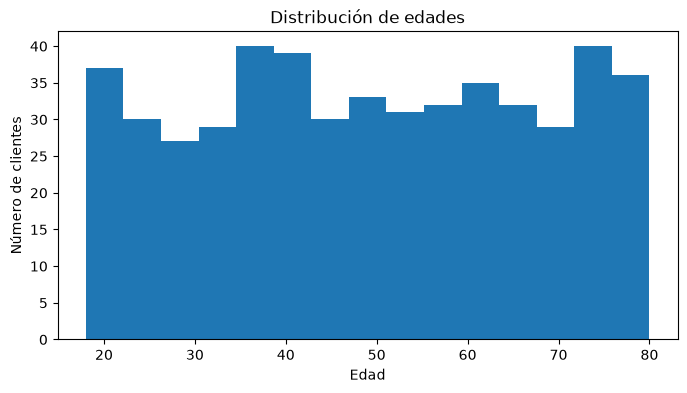

In [16]:
# ¿Tenemos clientes de todas las edades o se concentran en algún rango?
plt.figure(figsize=(8,4))

plt.hist(
    df_clientes["edad"],
    bins=15
)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")

plt.show()

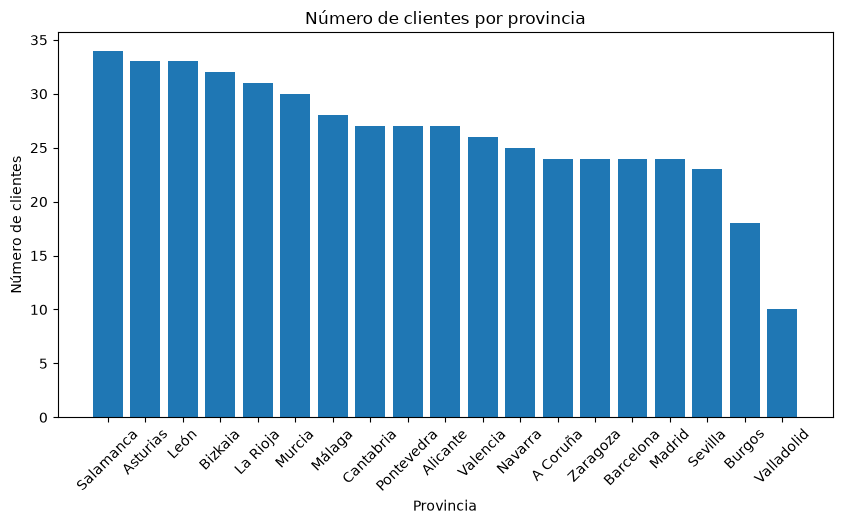

In [17]:
# ¿En qué provincias tenemos más clientes?
clientes_provincia = (
    df_clientes
    .group_by("provincia")
    .agg(pl.len().alias("num_clientes"))
    .sort("num_clientes", descending=True)
)

clientes_provincia

plt.figure(figsize=(10,5))

plt.bar(
    clientes_provincia["provincia"],
    clientes_provincia["num_clientes"]
)

plt.xticks(rotation=45)

plt.title("Número de clientes por provincia")
plt.xlabel("Provincia")
plt.ylabel("Número de clientes")

plt.show()

## Ejercicio 1: Plantea otras 5 preguntas para explorar el csv de clientes. 

In [18]:
# ¿Cuantos socios son hombre o mujer?
porcentaje_socios = df_clientes.group_by("sexo").agg(
    pl.len().alias("total"),
    pl.col("socio").sum().alias("socios")
).with_columns(
    (pl.col("socios") / pl.col("total") * 100).alias("porcentaje_socios")
)
porcentaje_socios


sexo,total,socios,porcentaje_socios
str,u32,u32,f64
"""Mujer""",269,158,58.736059
"""Hombre""",231,128,55.411255


In [19]:
#Cuales son los nombres mas repetidos de nuestros clientes
nombres_repetidos = df_clientes.group_by("nombre").agg(
    pl.len().alias("total"),
).sort("total", descending=True).head(10)
nombres_repetidos

nombre,total
str,u32
"""Laura""",31
"""Carlos""",30
"""Marta""",27
"""María""",27
"""Paula""",25
"""Sergio""",24
"""Ana""",22
"""Lucía""",22
"""Miguel""",22


In [20]:
# El primer cliente dado de alta
df_clientes.sort("fecha_alta").select(["nombre","apellidos","fecha_alta"]).head(1)

nombre,apellidos,fecha_alta
str,str,str
"""Iván""","""Moreno Álvarez""","""2022-01-01"""


## Ejercicio 2: Plantea 2 visualizaciones que puedan dar resultado a dos de las preguntas planteadas.

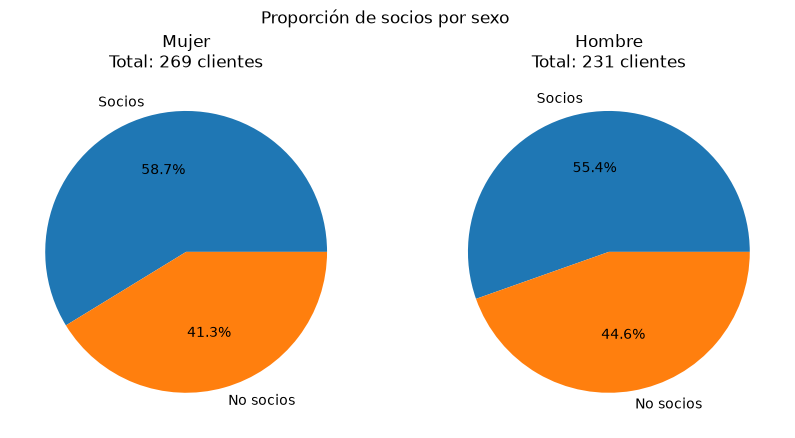

In [21]:
#Este código crea un gráfico de torta para cada sexo, mostrando la proporción de socios y no socios. Además, se muestra el total de clientes para cada sexo en el título del gráfico.
sexos = porcentaje_socios["sexo"].to_list()

# Crear un gráfico de torta(subplot)
# En este caso, se crean subplots para cada sexo(mediante len(sexos))
fig, axes = plt.subplots(1, len(sexos), figsize=(10, 5))

#Se utiliza un bucle para iterar sobre los sexos y 
# Creando un gráfico de torta para cada uno. Se muestra el porcentaje de socios y no socios
for ax, sexo in zip(axes, sexos):
    fila = porcentaje_socios.filter(pl.col("sexo") == sexo)

    porcentaje = fila["porcentaje_socios"][0]
    total = fila["total"][0]

    ax.pie(
        [porcentaje, 100 - porcentaje],
        labels=["Socios", "No socios"],
        #Muestra el porcentaje de cada sección en el gráfico de torta con un decimal
        autopct="%1.1f%%"
    )

    ax.set_title(f"{sexo}\nTotal: {total} clientes")

plt.suptitle("Proporción de socios por sexo")
plt.show()

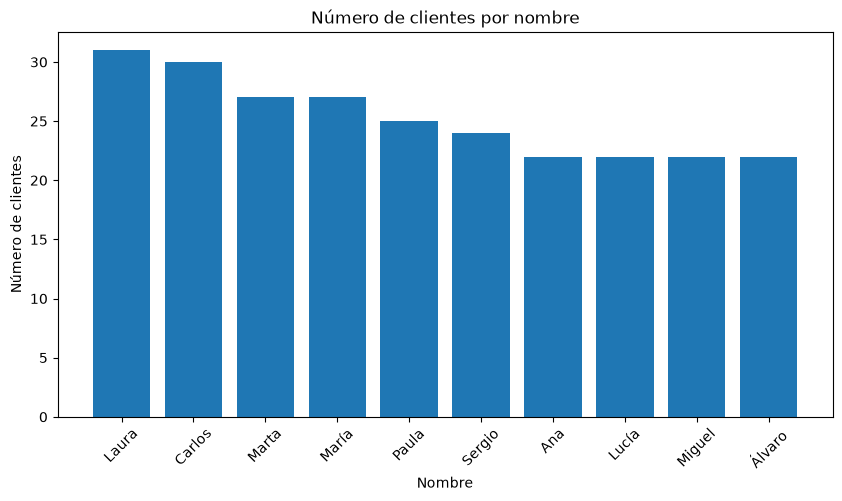

In [22]:

plt.figure(figsize=(10,5))

plt.bar(
    nombres_repetidos["nombre"],
    nombres_repetidos["total"]
)

plt.xticks(rotation=45)

plt.title("Número de clientes por nombre")
plt.xlabel("Nombre")
plt.ylabel("Número de clientes")

plt.show()

## Ejercicio 3: Repite exactamente lo mismo con los otros dos csvs.

# 2. Productos

In [23]:
# Leer el csv de clientes
df_productos = pl.read_csv("../data/productos.csv")

In [24]:
#Cabecera del dataset
df_productos.head()

id_producto,nombre,categoria,marca,precio,coste
i64,str,str,str,f64,f64
1,"""Barra""","""Panadería""","""Casa Tarradellas""",8.49,4.38
2,"""Snacks perro""","""Mascotas""","""Casa Tarradellas""",9.92,6.73
3,"""Detergente""","""Limpieza""","""Pascual""",5.45,2.48
4,"""Calamares""","""Pescados""","""Font Vella""",14.94,9.11
5,"""Turrón""","""Dulces""","""Font Vella""",4.37,2.18


In [25]:
#Columnas del dataset
df_productos.columns

['id_producto', 'nombre', 'categoria', 'marca', 'precio', 'coste']

In [26]:
#Columnas informacion
df_productos.dtypes

[Int64, String, String, String, Float64, Float64]

In [27]:
#Estructuracion del dataset
df_productos.shape

(150, 6)

In [28]:
#Comprobacion de valores extraños
df_productos.describe()


statistic,id_producto,nombre,categoria,marca,precio,coste
str,f64,str,str,str,f64,f64
"""count""",150.0,"""150""","""150""","""150""",150.0,150.0
"""null_count""",0.0,"""0""","""0""","""0""",0.0,0.0
"""mean""",75.5,null,null,null,6.272067,3.750533
"""std""",43.445368,null,null,null,4.228993,2.676499
"""min""",1.0,"""Aceitunas""","""Bebidas""","""Bimbo""",0.5,0.32
"""25%""",38.0,null,null,null,3.08,1.72
"""50%""",76.0,null,null,null,5.64,3.27
"""75%""",113.0,null,null,null,8.45,4.79
"""max""",150.0,"""Zumo""","""Verduras""","""SuperData""",18.52,12.65


In [29]:
#Cargamos las diferentes categorias de los productos
df_productos["categoria"].value_counts()


categoria,count
str,u32
"""Bebidas""",11
"""Pescados""",9
"""Desayuno""",6
"""Bebé""",10
"""Mascotas""",13
…,…
"""Congelados""",5
"""Limpieza""",7
"""Lácteos""",5


In [30]:
df_productos["marca"].value_counts()

marca,count
str,u32
"""Pascual""",8
"""Danone""",10
"""Hero""",13
"""Central Lechera Asturiana""",19
"""Nestlé""",12
…,…
"""Casa Tarradellas""",16
"""Font Vella""",10
"""SuperData""",7


In [31]:
df_productos.group_by("categoria").agg(
    pl.mean("precio").alias("precio_medio")
)

categoria,precio_medio
str,f64
"""Higiene""",5.26
"""Lácteos""",3.408
"""Pescados""",13.035556
"""Bebé""",8.671
"""Frutas""",4.477
…,…
"""Mascotas""",8.954615
"""Limpieza""",8.854286
"""Carnes""",12.763333


In [32]:
cantidad_marcas =df_productos.group_by("marca").agg(
    pl.len().alias("num_productos")
).sort("num_productos", descending=True).head(5)
cantidad_marcas

marca,num_productos
str,u32
"""Central Lechera Asturiana""",19
"""Bimbo""",16
"""Casa Tarradellas""",16
"""Hero""",13
"""Campofrío""",12


In [33]:
#Filtramos los datos para obtener los productos de la categoria "Pescados" con un precio mayor a 10
# Ademas, los ordenamos de mayor a menor precio
pescados_caros = df_productos.filter((pl.col("precio")>10)& (pl.col("categoria")=="Pescados")).sort("precio", descending=True)
pescados_caros

id_producto,nombre,categoria,marca,precio,coste
i64,str,str,str,f64,f64
109,"""Merluza""","""Pescados""","""Casa Tarradellas""",16.26,10.74
54,"""Bacalao""","""Pescados""","""Campofrío""",15.81,8.82
18,"""Langostinos""","""Pescados""","""Campofrío""",15.7,10.95
96,"""Atún""","""Pescados""","""Bimbo""",15.09,9.96
4,"""Calamares""","""Pescados""","""Font Vella""",14.94,9.11
49,"""Calamares""","""Pescados""","""Central Lechera Asturiana""",13.36,7.36
43,"""Salmón""","""Pescados""","""Central Lechera Asturiana""",11.2,6.17
117,"""Calamares""","""Pescados""","""Central Lechera Asturiana""",10.35,6.07


In [34]:
#Calcular los 5 productos mas baratos del super mercado
df_productos.group_by("nombre").agg(
    pl.col("precio").min().alias("precio_minimo")
).sort("precio_minimo",descending=False).head(5)

nombre,precio_minimo
str,f64
"""Café""",0.5
"""Galletas""",0.5
"""Verduras congeladas""",0.59
"""Uva""",0.6
"""Patatas fritas""",0.64


In [35]:
#Agrupamos los productos por marca y obtenemos las categorias unicas de cada marca
df_productos.group_by("marca").agg(
    pl.col("categoria").unique().alias("categorias")
)

marca,categorias
str,list[str]
"""Casa Tarradellas""","[""Panadería"", ""Mascotas"", … ""Pescados""]"
"""Pascual""","[""Limpieza"", ""Verduras"", … ""Frutas""]"
"""Campofrío""","[""Higiene"", ""Pescados"", … ""Bebidas""]"
"""Danone""","[""Panadería"", ""Frutas"", … ""Desayuno""]"
"""Gallina Blanca""","[""Desayuno"", ""Lácteos"", … ""Panadería""]"
…,…
"""Nestlé""","[""Bebé"", ""Bebidas"", … ""Pescados""]"
"""ElPozo""","[""Bebé"", ""Frutas"", … ""Verduras""]"
"""Hero""","[""Verduras"", ""Bebé"", … ""Dulces""]"


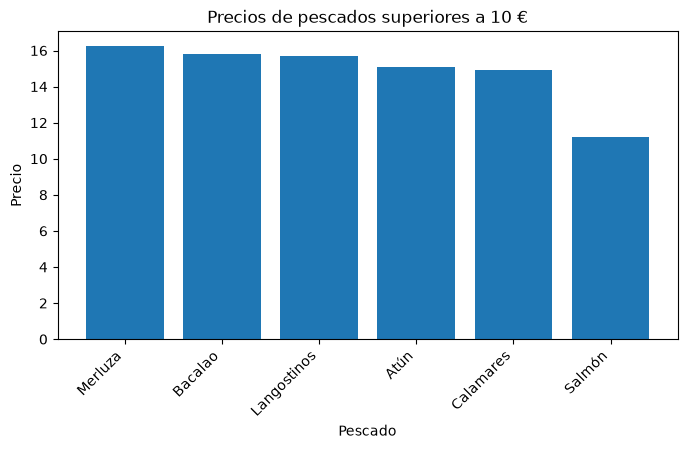

In [36]:
# Distribución de precios de los pescados cuyo precio es mayor que 10
plt.figure(figsize=(8, 4))

plt.bar(
    pescados_caros["nombre"],
    pescados_caros["precio"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Precios de pescados superiores a 10 €")
plt.xlabel("Pescado")
plt.ylabel("Precio")

plt.show()

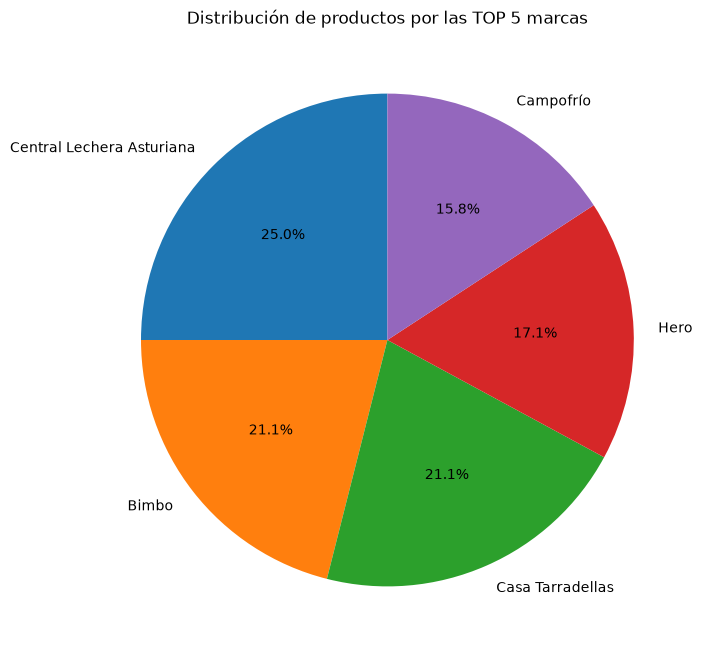

In [37]:
plt.figure(figsize=(8, 8))

plt.pie(
    cantidad_marcas["num_productos"].to_list(),
    labels=cantidad_marcas["marca"].to_list(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de productos por las TOP 5 marcas")
plt.show()


# 3. Ventas

In [38]:
df_ventas = pl.read_csv("../data/ventas.csv")
df_ventas

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento
i64,str,i64,i64,i64,str,i64
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0
…,…,…,…,…,…,…
9996,"""2025-06-03 13:00:00""",301,90,3,"""Tarjeta""",0
9997,"""2025-08-22 22:00:00""",295,48,3,"""Cheque regalo""",10
9998,"""2025-06-14 09:00:00""",43,126,5,"""Tarjeta""",10


In [39]:
#Mostramos cabecera del dataset
df_ventas.head()

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento
i64,str,i64,i64,i64,str,i64
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0


In [40]:
df_ventas.columns

['id_venta',
 'fecha',
 'id_cliente',
 'id_producto',
 'cantidad',
 'metodo_pago',
 'descuento']

In [41]:
df_ventas.shape

(10000, 7)

In [42]:
#Columnas informacion
df_productos.dtypes

[Int64, String, String, String, Float64, Float64]

In [43]:
df_ventas['metodo_pago'].value_counts()

metodo_pago,count
str,u32
"""Efectivo""",1495
"""Tarjeta""",6026
"""Cheque regalo""",474
"""Bizum""",2005


In [44]:
ventas_detalle = (
    df_ventas
    .join(
        df_clientes.select(["id_cliente", "nombre", "apellidos"]),
        on="id_cliente",
        how="left"
    )
    .join(
        df_productos.select(["id_producto", "nombre"]),
        on="id_producto",
        how="left",
    )
)

ventas_detalle

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento,nombre,apellidos,nombre_right
i64,str,i64,i64,i64,str,i64,str,str,str
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10,"""Ana""","""Vázquez Martín""","""Barra"""
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5,"""Jorge""","""Torres Álvarez""","""Lejía"""
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0,"""Álvaro""","""Díaz Gómez""","""Pipas"""
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0,"""Carlos""","""Díaz Castro""","""Atún"""
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0,"""David""","""Gómez Muñoz""","""Pipas"""
…,…,…,…,…,…,…,…,…,…
9996,"""2025-06-03 13:00:00""",301,90,3,"""Tarjeta""",0,"""Ana""","""Sánchez Navarro""","""Mandarina"""
9997,"""2025-08-22 22:00:00""",295,48,3,"""Cheque regalo""",10,"""Sergio""","""Navarro Martínez""","""Frutos secos"""
9998,"""2025-06-14 09:00:00""",43,126,5,"""Tarjeta""",10,"""Alejandro""","""Torres Fernández""","""Brócoli"""


In [45]:
#Mostramos las ventas que han sido con trajeta y los cliente que la han efectuado
ventas_por_cliente = (
    ventas_detalle.filter(pl.col("metodo_pago")=="Tarjeta")
    .group_by(["id_cliente","nombre","apellidos"]).agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
    )

    )
ventas_por_cliente.sort("total_cantidad", descending=True).head(10)

id_cliente,nombre,apellidos,num_ventas,total_cantidad
i64,str,str,u32,i64
498,"""Jorge""","""Torres Sánchez""",34,82
112,"""Iván""","""López Navarro""",34,82
182,"""Miguel""","""Romero Álvarez""",30,78
210,"""Pablo""","""Sánchez López""",33,76
245,"""Julia""","""Álvarez García""",31,75
357,"""Paula""","""López Fernández""",33,74
57,"""Andrea""","""Pérez Pérez""",34,73
69,"""Ana""","""García García""",36,72
27,"""Álvaro""","""Díaz Gómez""",30,70


In [46]:
# Mostramos las ventas pagadas con cheque regalo, agrupadas por producto
# e indicando el número de ventas y la cantidad total de unidades vendidas.
ventas_por_productos = (
    ventas_detalle.filter(pl.col("metodo_pago") == "Cheque regalo")
    .group_by(["id_producto", "nombre_right"])
    .agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
    )
)
ventas_por_productos.sort("total_cantidad", descending=True).head(10)

id_producto,nombre_right,num_ventas,total_cantidad
i64,str,u32,i64
120,"""Kiwi""",8,24
59,"""Caramelos""",8,21
126,"""Brócoli""",7,18
63,"""Atún""",6,17
114,"""Salchichas""",5,17
74,"""Cebolla""",7,17
150,"""Cerveza""",6,17
27,"""Frutos secos""",7,16
88,"""Leche infantil""",5,15


In [47]:
#Mostramos las ventas que han tenido algun descuento, agrupadas por cliente y mostrando el numero de ventas, la cantidad total y el descuento total aplicado
ventas_con_descuento = (
    ventas_detalle.filter(pl.col("descuento")>0)
    .group_by(["id_cliente","nombre","apellidos"])
    .agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
        pl.sum("descuento").alias("total_descuento")
    )
)
ventas_con_descuento

id_cliente,nombre,apellidos,num_ventas,total_cantidad,total_descuento
i64,str,str,u32,i64,i64
122,"""Miguel""","""Ortega Moreno""",2,3,20
457,"""Rubén""","""Martínez Gómez""",16,38,135
444,"""Sergio""","""Navarro Vázquez""",7,13,65
357,"""Paula""","""López Fernández""",22,51,195
388,"""Miguel""","""Sánchez Álvarez""",11,27,95
…,…,…,…,…,…
483,"""Sergio""","""Martínez Martín""",9,21,70
13,"""Pablo""","""Pérez Torres""",1,2,5
90,"""Rubén""","""Ortega Ruiz""",4,7,45


In [48]:
#Mostramos quienes son los clientes que mas compran el mismo producto
ventas_cliente_producto = (
    ventas_detalle.group_by(["id_cliente","nombre","apellidos","id_producto","nombre_right"]).agg(
        pl.len().alias("num_ventas"))
).sort("num_ventas", descending=True).head(10)
ventas_cliente_producto

id_cliente,nombre,apellidos,id_producto,nombre_right,num_ventas
i64,str,str,i64,str,u32
255,"""Marta""","""Gómez Ruiz""",65,"""Plátano""",4
41,"""Carmen""","""Castro Pérez""",36,"""Verduras congeladas""",4
381,"""Sergio""","""Romero Díaz""",141,"""Patatas fritas""",3
203,"""Carmen""","""Díaz Martín""",35,"""Toallitas""",3
143,"""Sofía""","""Sánchez Romero""",124,"""Ternera""",3
16,"""Carlos""","""Vázquez Romero""",123,"""Pipas""",3
182,"""Miguel""","""Romero Álvarez""",128,"""Pasta de dientes""",3
343,"""Miguel""","""Pérez Moreno""",111,"""Zumo""",3
388,"""Miguel""","""Sánchez Álvarez""",70,"""Pañales""",3


In [49]:
#Mostramos lo que mas compra nuestro cliente con mas compras realizadas
compras_jorge = ventas_detalle.filter(pl.col("id_cliente")==498).group_by(["id_producto","nombre_right"],).agg(
    pl.len().alias("num_ventas"),
    pl.sum("cantidad").alias("total_cantidad"),
    pl.sum("descuento").alias("total_descuento")
)
compras_jorge.sort("total_cantidad", descending=True).head(10)

id_producto,nombre_right,num_ventas,total_cantidad,total_descuento
i64,str,u32,i64,i64
104,"""Pan Integral""",2,8,5
138,"""Chicles""",2,5,0
84,"""Zumo""",1,5,0
59,"""Caramelos""",2,5,0
65,"""Plátano""",2,5,5
21,"""Uva""",1,4,20
149,"""Pañales""",1,4,0
46,"""Snacks perro""",1,4,0
117,"""Calamares""",2,4,5


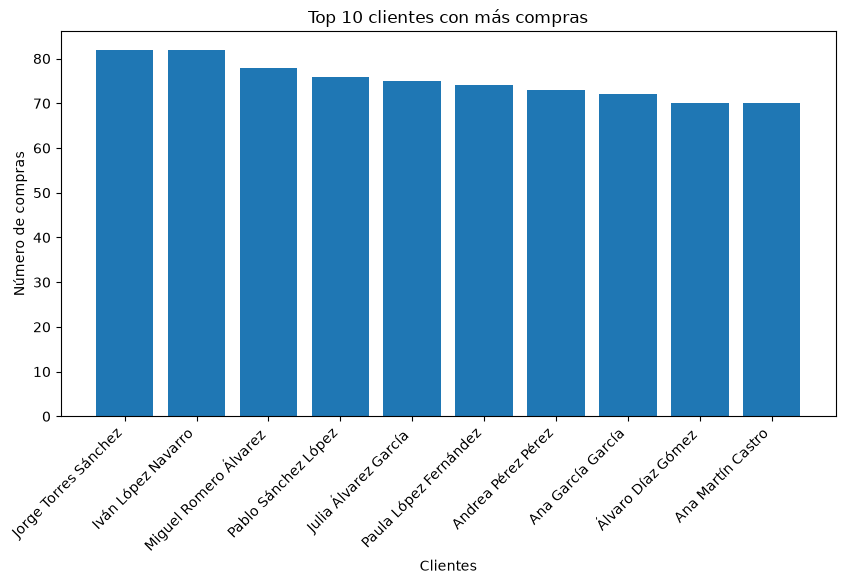

In [50]:
ventas_ordenadas = ventas_por_cliente.sort(
    "total_cantidad",
    descending=True
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    ventas_ordenadas["nombre"] + " " + ventas_ordenadas["apellidos"],
    ventas_ordenadas["total_cantidad"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 clientes con más compras")
plt.xlabel("Clientes")
plt.ylabel("Número de compras")

plt.show()

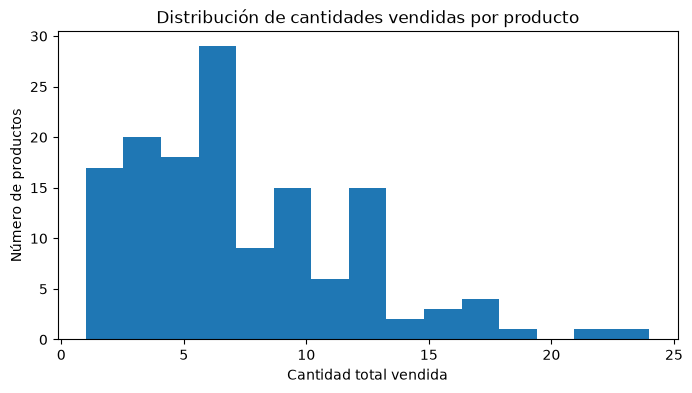

In [51]:
plt.figure(figsize=(8, 4))

plt.hist(
    ventas_por_productos["total_cantidad"].to_list(),
    bins=15,
)

plt.title("Distribución de cantidades vendidas por producto")
plt.xlabel("Cantidad total vendida")
plt.ylabel("Número de productos")

plt.show()

**Entrega**

Un documento de tres caras (una por cada csv) con los resultados de la exploración y las visualizaciones correspondientes.